In [1]:
from research_tables import summarize, leaderboard
from research_plots import set_theme, bar, line, magic_quadrant, violin
from eval_helpers import read_dataset
set_theme()

df = read_dataset("eval_results")

In [11]:
import pandas as pd
# 1. Fill NaNs so successes are counted
df["failure_mode"] = df["failure_mode"].fillna("success")

index_cols = ["backend", "fc_model", "reasoning_effort", "wire_api"]
col_cols = ["failure_mode"]

# 2. Filter your data first using your query
filtered_df = df.query("reasoning_effort == 'medium' and python_enabled == 0 and test_type != 'GPT-OSS'")

# 3. Calculate seed-level distributions (0-100%)
counts = filtered_df.groupby(index_cols + ["seed", "failure_mode"]).size().unstack(fill_value=0)
pcts = counts.div(counts.sum(axis=1), axis=0)

# 4. Compute mean and standard deviation across seeds
mean_pcts = pcts.groupby(level=index_cols).mean()
std_pcts = pcts.groupby(level=index_cols).std().fillna(0)

# 5. Combine and flatten to match your leaderboard's expected 'out' structure
out = pd.concat([
    mean_pcts.stack().rename("mean_pct"),
    std_pcts.stack().rename("std_pct")
], axis=1).reset_index()

# 6. Render using your existing leaderboard function
tbl = leaderboard(
    out, 
    index_cols, 
    col_cols, 
    value_col="mean_pct", 
    error_col="std_pct",
    higher_is_better=True, # Highlight the highest success/failure rate
    precision=4, 
    caption=None
)
df_debug = df[(df["backend"] == "llamacpp@fixed-jinja") & (df["failure_mode"] == 'model')]
display(df["test_name"].value_counts())

LeaderboardTable(styler=<pandas.io.formats.style.Styler object at 0x71eb73ee4aa0>, numeric=failure_mode                                                   infra  \
backend                fc_model reasoning_effort wire_api              
burrito@llamacpp       0        medium           chat       0.000890   
                                                 responses  0.000791   
                       1        medium           chat       0.000000   
                                                 responses  0.000000   
burrito@vllm           0        medium           chat       0.003362   
                                                 responses  0.003263   
                       1        medium           chat       0.000099   
                                                 responses  0.000099   
llamacpp@default-jinja 0        medium           chat       0.022943   
                                                 responses  0.022943   
                       1        medium           chat       0.003758   
                                                 responses  0.003758   
llamacpp@fixed-jinja   0        medium           chat       0.415051   
                                                 responses  0.415051   
                       1        medium           chat       0.003758   
                                                 responses  0.003758   
vllm                   0        medium           chat       0.010186   
                                                 responses  0.068335   
                       1        medium           chat       0.007911   
                                                 responses  0.045392   

failure_mode                                                   model   success  
backend                fc_model reasoning_effort wire_api                       
burrito@llamacpp       0        medium           chat       0.436709  0.562401  
                                                 responses  0.436610  0.562599  
                       1        medium           chat       0.238232  0.761768  
                                                 responses  0.239419  0.760581  
burrito@vllm           0        medium           chat       0.396657  0.599980  
                                                 responses  0.396657  0.600079  
                       1        medium           chat       0.232496  0.767405  
                                                 responses  0.232595  0.767306  
llamacpp@default-jinja 0        medium           chat       0.755538  0.221519  
                                                 responses  0.755538  0.221519  
                       1        medium           chat       0.248220  0.748022  
                                                 responses  0.248220  0.748022  
llamacpp@fixed-jinja   0        medium           chat       0.130142  0.454806  
                                                 responses  0.130142  0.454806  
                       1        medium           chat       0.248220  0.748022  
                                                 responses  0.248220  0.748022  
vllm                   0        medium           chat       0.784810  0.205004  
                                                 responses  0.700059  0.231606  
                       1        medium           chat       0.284118  0.707971  
                                                 responses  0.227848  0.726760  , error=failure_mode                                                   infra  \
backend                fc_model reasoning_effort wire_api              
burrito@llamacpp       0        medium           chat       0.000660   
                                                 responses  0.000732   
                       1        medium           chat       0.000000   
                                                 responses  0.000000   
burrito@vllm           0        medium           chat       0.003481   
                               

test_name
simple_python        89600
live_simple          57792
irrelevance          53760
multi_turn_base      44800
simple_java          22400
GPQA                 17028
simple_javascript    11200
live_relevance        3584
AIME25                2580
Name: count, dtype: int64

In [36]:
# intra seed stability INCLUDING CRASHED RUNS
import pandas as pd

index_cols = ["backend", "fc_model", "reasoning_effort", "test_name"]
col_cols = ["consistency_mode"]

# 1. Apply your test filter query first
filtered_df = df.query("reasoning_effort == 'medium' and python_enabled == 0 and test_type != 'GPT-OSS' and fc_model == 0 and wire_api == 'chat'")

# 2. Group by configuration and test_id to count correct runs across seeds
test_stats = filtered_df.groupby(index_cols + ["test_id"])["correct"].agg(["sum", "count"])
test_stats["success_rate"] = test_stats["sum"] / test_stats["count"]

# 3. Categorize each test_id as a percentage (0 to 100%)
test_stats["always_correct"] = (test_stats["success_rate"] == 1.0).astype(float) * 100
test_stats["always_wrong"] = (test_stats["success_rate"] == 0.0).astype(float) * 100
test_stats["inconsistent"] = ((test_stats["success_rate"] > 0.0) & (test_stats["success_rate"] < 1.0)).astype(float) * 100

# 4. Average these classification rates per configuration group
agg_cols = ["always_correct", "always_wrong", "inconsistent"]
mean_df = test_stats.groupby(level=index_cols)[agg_cols].mean()

# Create a dummy std_df with 0.0 since this is an all-seed aggregate
std_df = pd.DataFrame(0.0, index=mean_df.index, columns=mean_df.columns)

# 5. Format to match your leaderboard's expected 'out' structure
out = pd.concat([
    mean_df.stack().rename("mean_val"),
    std_df.stack().rename("std_val")
], axis=1).reset_index()

# Dynamically identify and rename the stacked column
stacked_col = [c for c in out.columns if c not in index_cols + ["mean_val", "std_val"]][0]
out = out.rename(columns={stacked_col: "consistency_mode"})

# 6. Display via your leaderboard function
tbl = leaderboard(
    out, 
    index_cols, 
    col_cols, 
    value_col="mean_val", 
    error_col="std_val",
    higher_is_better=True, 
    precision=2, 
    caption="Consistency of answers across seeds (%) (INCLUDING CRASHED RUNS)"
)

LeaderboardTable(styler=<pandas.io.formats.style.Styler object at 0x71eb714bf9e0>, numeric=consistency_mode                                                    always_correct  \
backend                fc_model reasoning_effort test_name                           
burrito@llamacpp       0        medium           irrelevance             81.666667   
                                                 live_relevance          12.500000   
                                                 live_simple              6.976744   
                                                 multi_turn_base          0.000000   
                                                 simple_java             38.000000   
                                                 simple_javascript       22.000000   
                                                 simple_python            5.500000   
burrito@vllm           0        medium           irrelevance             81.666667   
                                                 live_relevance          12.500000   
                                                 live_simple             14.728682   
                                                 multi_turn_base          0.000000   
                                                 simple_java             41.000000   
                                                 simple_javascript       24.000000   
                                                 simple_python           11.750000   
llamacpp@default-jinja 0        medium           irrelevance             98.333333   
                                                 live_relevance           0.000000   
                                                 live_simple              0.000000   
                                                 multi_turn_base          0.000000   
                                                 simple_java              0.000000   
                                                 simple_javascript        0.000000   
                                                 simple_python            0.000000   
llamacpp@fixed-jinja   0        medium           irrelevance             80.000000   
                                                 live_relevance           6.250000   
                                                 live_simple              1.162791   
                                                 multi_turn_base          0.500000   
                                                 simple_java             42.000000   
                                                 simple_javascript       18.000000   
                                                 simple_python            0.250000   
vllm                   0        medium           irrelevance             97.916667   
                                                 live_relevance           0.000000   
                                                 live_simple              0.000000   
                                                 multi_turn_base          0.000000   
                                                 simple_java              0.000000   
                                                 simple_javascript        0.000000   
                                                 simple_python            0.000000   

consistency_mode                                                    always_wrong  \
backend                fc_model reasoning_effort test_name                         
burrito@llamacpp       0        medium           irrelevance            0.416667   
                                                 live_relevance        12.500000   
                                                 live_simple            8.914729   
                                                 multi_turn_base       46.500000   
                                                 simple_java           33.000000   
                                                 simple_javascript     20.000000   
                                                 simpl

In [31]:
import pandas as pd

# Fill NaNs to classify failure modes first
df["failure_mode"] = df["failure_mode"].fillna("success")

index_cols = ["backend", "fc_model", "reasoning_effort", "wire_api"]
col_cols = ["consistency_mode"]

# 1. Filter raw df for just the test suite you are evaluating
test_suite_df = df.query("reasoning_effort == 'medium' and python_enabled == 0 and test_type != 'GPT-OSS' and not test_name.str.startswith('irrelevance', na=False) ")
display(pd.crosstab(
    index=[test_suite_df["backend"], 
           test_suite_df["fc_model"], 
           test_suite_df["reasoning_effort"],
           test_suite_df["python_enabled"],
           test_suite_df["test_type"],
           ], 
    columns=test_suite_df["test_name"]
))
# 2. Identify all (test_id, seed) pairs that crashed on ANY backend [1]
crashed_runs = test_suite_df.query("failure_mode == 'infra'")[["test_id", "seed"]].drop_duplicates()

# 3. Create a MultiIndex of these crashed keys
crashed_keys = pd.MultiIndex.from_frame(crashed_runs)

# 4. Filter the test suite to globally exclude those keys [1]
# We temporarily set the index to (test_id, seed) to perform a fast, clean filter
paired_df = test_suite_df.set_index(["test_id", "seed"])
paired_df = paired_df[~paired_df.index.isin(crashed_keys)].reset_index()

# 5. Calculate consistency metrics on the perfectly aligned "surviving" dataset [1]
test_stats = paired_df.groupby(index_cols + ["test_id"])["correct"].agg(["sum", "count"])

# Safety check: Drop any test that was completely wiped out on all seeds globally
test_stats = test_stats[test_stats["count"] > 0]

# Calculate success rate dynamically (which is now perfectly balanced across backends) [1]
test_stats["success_rate"] = test_stats["sum"] / test_stats["count"]

# 6. Categorize each test_id as a percentage (0 to 100%)
test_stats["always_correct"] = (test_stats["success_rate"] == 1.0).astype(float) * 100
test_stats["always_wrong"] = (test_stats["success_rate"] == 0.0).astype(float) * 100
test_stats["inconsistent"] = ((test_stats["success_rate"] > 0.0) & (test_stats["success_rate"] < 1.0)).astype(float) * 100

# 7. Average these classification rates per configuration group
agg_cols = ["always_correct", "always_wrong", "inconsistent"]
mean_df = test_stats.groupby(level=index_cols)[agg_cols].mean()

# Create a dummy std_df with 0.0 since this is an all-seed aggregate
std_df = pd.DataFrame(0.0, index=mean_df.index, columns=mean_df.columns)

# 8. Format to match your leaderboard's expected 'out' structure
out = pd.concat([
    mean_df.stack().rename("mean_val"),
    std_df.stack().rename("std_val")
], axis=1).reset_index()

# Dynamically identify and rename the stacked column
stacked_col = [c for c in out.columns if c not in index_cols + ["mean_val", "std_val"]][0]
out = out.rename(columns={stacked_col: "consistency_mode"})

# 9. Display via your leaderboard function
tbl = leaderboard(
    out, 
    index_cols, 
    col_cols, 
    value_col="mean_val", 
    error_col="std_val",
    higher_is_better=True, 
    precision=2, 
    caption="Fairly Paired Model Consistency (Crashes Excluded Globally) (%)"
)

test_name                                                                   live_relevance  \
backend                fc_model reasoning_effort python_enabled test_type                    
burrito@llamacpp       0        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
                       1        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
burrito@vllm           0        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
                       1        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
llamacpp@default-jinja 0        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
                       1        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
llamacpp@fixed-jinja   0        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
                       1        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
vllm                   0        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   
                       1        medium           0              live                   256   
                                                                multi_turn               0   
                                                                non_live                 0   

test_name                                                                   live_simple  \
backend                fc_model reasoning_effort python_enabled test_type                 
burrito@llamacpp       0        medium           0              live               4128   
                                                                multi_turn            0   
                                                                non_live              0   
                       1        medium           0              live               4128   
                                                                multi_turn            0   
                                                                non_live              0   
burrito@vllm           0        medium           0              live               4128   
                                                                multi_turn            0   
                                                                non_live         

LeaderboardTable(styler=<pandas.io.formats.style.Styler object at 0x71eb71510ec0>, numeric=consistency_mode                                            always_correct  \
backend                fc_model reasoning_effort wire_api                    
burrito@llamacpp       0        medium           chat            27.422907   
                                                 responses       27.312775   
                       1        medium           chat            61.894273   
                                                 responses       62.004405   
burrito@vllm           0        medium           chat            29.185022   
                                                 responses       29.185022   
                       1        medium           chat            62.995595   
                                                 responses       62.995595   
llamacpp@default-jinja 0        medium           chat             0.000000   
                                                 responses        0.000000   
                       1        medium           chat            59.581498   
                                                 responses       59.581498   
llamacpp@fixed-jinja   0        medium           chat            64.867841   
                                                 responses       64.867841   
                       1        medium           chat            59.581498   
                                                 responses       59.581498   
vllm                   0        medium           chat             0.000000   
                                                 responses        0.000000   
                       1        medium           chat            56.057269   
                                                 responses       58.259912   

consistency_mode                                            always_wrong  \
backend                fc_model reasoning_effort wire_api                  
burrito@llamacpp       0        medium           chat          23.788546   
                                                 responses     23.678414   
                       1        medium           chat          15.198238   
                                                 responses     15.088106   
burrito@vllm           0        medium           chat          23.788546   
                                                 responses     23.678414   
                       1        medium           chat          14.207048   
                                                 responses     14.207048   
llamacpp@default-jinja 0        medium           chat          83.259912   
                                                 responses     83.259912   
                       1        medium           chat          15.638767   
                                                 responses     15.638767   
llamacpp@fixed-jinja   0        medium           chat          15.198238   
                                                 responses     15.198238   
                       1        medium           chat          15.638767   
                                                 responses     15.638767   
vllm                   0        medium           chat          89.647577   
                                                 responses     80.947137   
                       1        medium           chat          18.171806   
                                                 responses     16.519824   

consistency_mode                                            inconsistent  
backend                fc_model reasoning_effort wire_api                 
burrito@llamacpp       0        medium           chat          48.788546  
                                                 responses     49.008811  
                       1        medium           chat          22.907489  
                                                 responses     22.907489  
burrito@vllm           0        medium           chat          47.026

In [33]:
# 1. Filter to the specific baseline slice you want to compare
# Adding wire_api and reasoning_effort here guarantees uniqueness [1, 2]
compare_df = test_suite_df.query(
    "backend in ['llamacpp@fixed-jinja', 'burrito@llamacpp'] and "
    "fc_model == 0 and "
    "test_name != 'GPT-OSS' and "
    "wire_api == 'chat' and "
    "reasoning_effort == 'medium' "
    "and is_error == 0"
)

# 2. Pivot so each backend's 'correct' score is side-by-side [2]
pivoted = compare_df.pivot(
    index=["test_id", "seed"], 
    columns="backend", 
    values="correct"
)

# 3. Find cases where native got 1 (correct) but burrito got 0 (incorrect) [1]
mismatches = pivoted[
    (pivoted["llamacpp@fixed-jinja"] == 1) & 
    (pivoted["burrito@llamacpp"] == 0)
]

# 4. Display the first 10 examples to investigate tomorrow
print(f"Found {len(mismatches)} total mismatched seed runs.")
display(mismatches.head(10))

# Copy one of the test_id and seed pairs from your mismatch list
target_test_id = "irrelevance_109" # Replace with an actual mismatch ID
target_seed = 819437                # Replace with the matching seed

# Query the log data for these exact runs
inspect_df = test_suite_df.query(
    f"test_id == '{target_test_id}' and seed == {target_seed} and "
    "backend in ['llamacpp@fixed-jinja', 'burrito@llamacpp'] and "
    "fc_model == 0 and "
    "test_name != 'GPT-OSS' and "
    "wire_api == 'chat' and "
    "reasoning_effort == 'medium' "
    "and is_error == 0"
)

# Print the model responses side-by-side
for idx, row in inspect_df.iterrows():
    print(f"\n========================================================")
    print(f" BACKEND: {row['backend']} | CORRECT: {row['correct']}")
    print(f"========================================================")
    
    # NOTE: Replace 'error_message' or 'error_type' with your actual column name
    # that stores the generated text/response (e.g., 'response', 'output', etc.)
    if 'response' in row:
        print(row['response'])
    else:
        print(f"Error Message: {row['error_message']}")
        print(f"Error Type: {row['error_type']}")

Found 922 total mismatched seed runs.


backend                           burrito@llamacpp  llamacpp@fixed-jinja
test_id                seed                                             
live_relevance_0-0-0   24601                   0.0                   1.0
                       680867                  0.0                   1.0
                       314159265               0.0                   1.0
live_relevance_1-1-0   1337                    0.0                   1.0
                       4201337                 0.0                   1.0
live_relevance_12-12-0 24601                   0.0                   1.0
live_relevance_14-14-0 24601                   0.0                   1.0
live_relevance_2-2-0   680867                  0.0                   1.0
live_relevance_3-3-0   24601                   0.0                   1.0
                       680867                  0.0                   1.0

(0.0, 1.0)

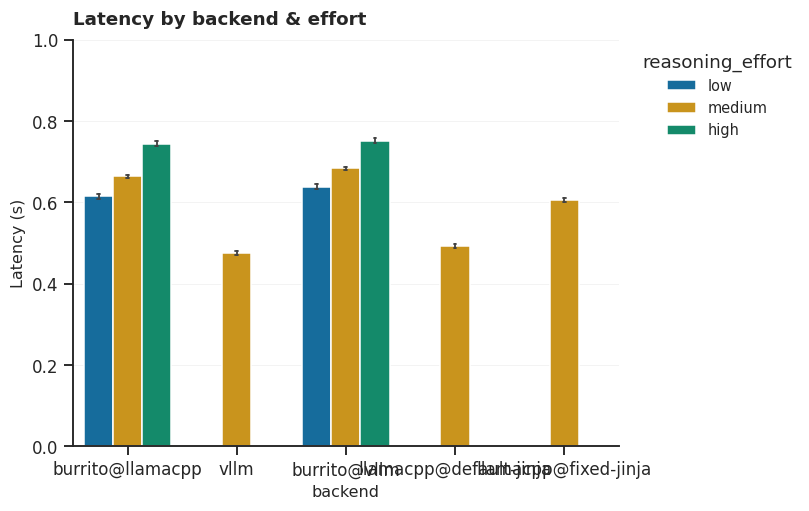

In [4]:
ax = bar(df, x="backend", y="correct", hue="reasoning_effort",
    title="Latency by backend & effort", ylabel="Latency (s)")
ax.set_ylim(0,1)

<Axes: title={'left': 'Latency distribution by effort'}, xlabel='reasoning_effort', ylabel='latency'>

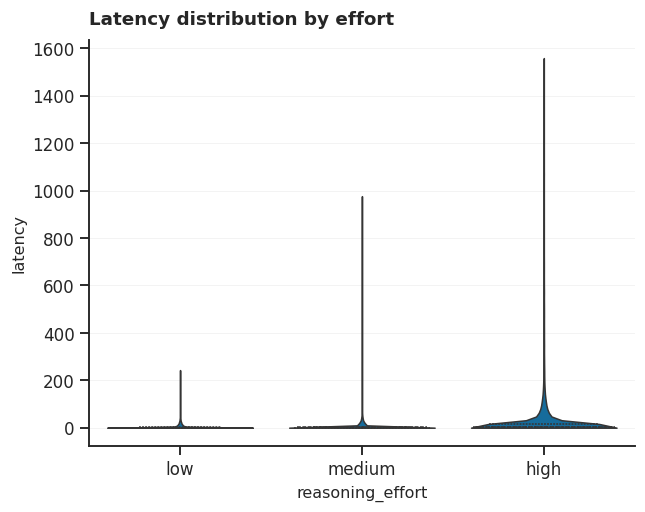

In [5]:
violin(df, x="reasoning_effort", y="latency",
       order=["low", "medium", "high"], title="Latency distribution by effort")

<Axes: title={'left': 'Accuracy vs reasoning effort'}, xlabel='reasoning_effort', ylabel='Correct rate'>

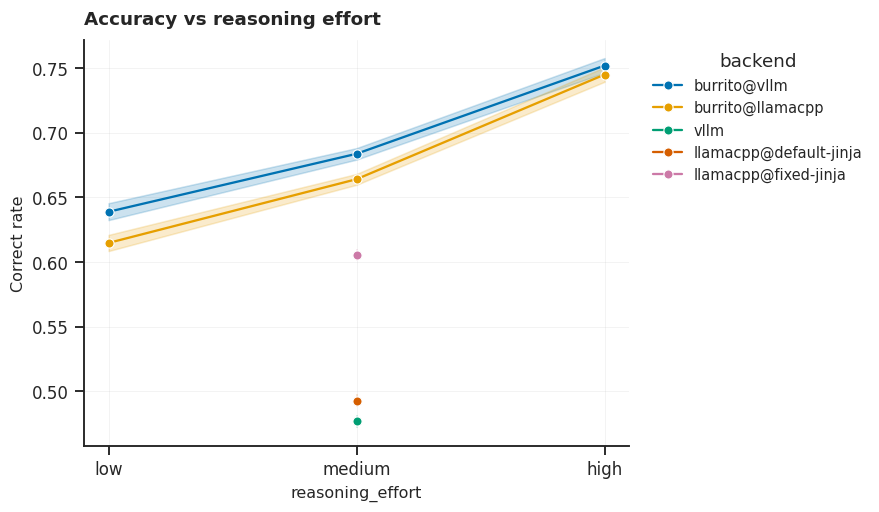

In [6]:
line(df, x="reasoning_effort", y="correct", hue="backend",
     order=["low", "medium", "high"],
     title="Accuracy vs reasoning effort", ylabel="Correct rate")

                   backend reasoning_effort   wire_api   correct    latency
1         burrito@llamacpp           medium       chat  0.521875  14.870919
0         burrito@llamacpp              low  responses  0.438125  11.301362
2         burrito@llamacpp           medium  responses  0.514375  15.130962
3         burrito@llamacpp             high  responses  0.510625  33.209191
5             burrito@vllm           medium       chat  0.561875  28.048780
4             burrito@vllm              low  responses  0.437500  23.144400
6             burrito@vllm           medium  responses  0.561250  27.816333
7             burrito@vllm             high  responses  0.508125  49.470844
8   llamacpp@default-jinja           medium       chat  0.503750  15.181410
9   llamacpp@default-jinja           medium  responses  0.503750  15.378488
10    llamacpp@fixed-jinja           medium       chat  0.503750  15.238552
11    llamacpp@fixed-jinja           medium  responses  0.503750  15.395561
12          

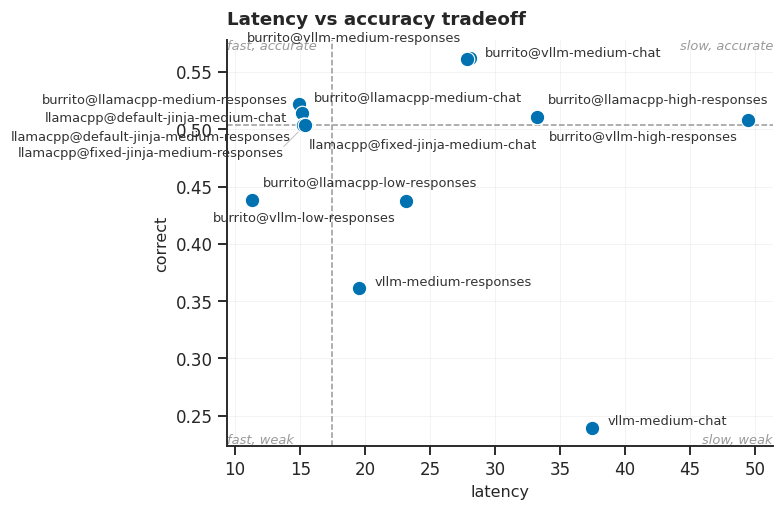

In [7]:
filtered = df.query("fc_model == 1 and test_name == 'multi_turn_base'")   # or: df[df["fc_model"] == 1]

agg = filtered.groupby(["backend", "reasoning_effort", "wire_api"]).agg(
    latency=("latency", "mean"), correct=("correct", "mean")
).reset_index()
print(agg[["backend", "reasoning_effort", "wire_api", "correct", "latency"]]
      .sort_values(["backend", "wire_api"]))
agg["config"] = agg["backend"].astype(str) + "-" + agg["reasoning_effort"].astype(str) + "-" + agg["wire_api"]

ax = magic_quadrant(agg, x="latency", y="correct", label="config",
               quadrant_labels=("fast, accurate", "slow, accurate",
                                 "fast, weak", "slow, weak"),
               title="Latency vs accuracy tradeoff")
# ax.set_ylim(0., 1.0)   # or ax.set_ylim(0, 1.05) to also fix the bottom